# Table of Contents

- [Exploratory Data Analysis (EDA)](#Exploratory-Data-Analysis-EDA)
- [Dataset Overview](#Dataset-Overview)
- [Missing Values](#Missing-Values)
- [Job Role Distribution](#Job-Role-Distribution)
- [Job Locations](#Job-Locations)
- [Salary Transparency](#Salary-Transparency)

- [Research Question Analysis](#Research-Question-Analysis)
  - [Skills Demand](#Skills-Demand)
    - [Average Skill Count by Role](#Average-Skill-Count-by-Role)
    - [Top 15 Most Frequently Requested Skills](#Top-15-Most-Frequently-Requested-Skills)
  - [Regional Differences](#Regional-Differences)
  - [Salary Transparency Patterns](#Salary-Transparency-Patterns)

- [Summary of Findings](#Summary-of-Findings)

# Exploratory Data Analysis (EDA)

This section explores the merged dataset containing Swiss job postings and macro-level vacancy statistics from the Swiss Federal Statistical Office (BFS). The objective is to understand the dataset structure, identify potential data quality issues, and explore key variables before addressing the research questions.

## Import Libraries

In this step, the necessary Python libraries for data analysis and visualization are imported. Pandas is used for data manipulation, NumPy for numerical operations, and Matplotlib and Seaborn for visualizations.

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Load the Dataset

The dataset used in this analysis contains the merged job postings data (micro-level data) and macro labor market statistics obtained from BFS (macro-level data). The dataset is loaded from the processed data folder of the project repository.

In [86]:
df = pd.read_csv("../data/processed/jobs_micro_macro_merged_final.csv")

df.head()

,job_id,role,title,company,city,canton,region,quarter,macro_quarter,skills,skill_count,salary_available,industry,regional_vacancies,industry_vacancies,source,url,description
0,43725c60f2a0e7a20223831427ec1c5733c8e34c,data scientist,Mission étudiante 40% : Data Analyst,Academic Work Switzerland,Montreux,VD,Lake Geneva Region,2026Q1,2025Q4,['power bi'],1,0,58-63 ICT,13400.0,4362.0,jobup,https://www.jobup.ch/en/jobs/detail/a5de724a-4...,about the job tu es actuellement étudiant.e ? ...
1,929b4733c6e1c66d045413a3373023e435e25a0c,data scientist,Junior Survey Data Analyst 20%,Academic Work Switzerland,Lausanne,VD,Lake Geneva Region,2026Q1,2025Q4,[],0,0,58-63 ICT,13400.0,4362.0,jobup,https://www.jobup.ch/en/jobs/detail/366613c5-e...,about the job tu es étudiant.e et recherches u...
2,da46ba822882645bc160031dd473b01555e8e9c8,data scientist,Merchandising & Data Analyst (H/F),Vilebrequin,Plan-les-Ouates,GE,Lake Geneva Region,2026Q1,2025Q4,[],0,0,58-63 ICT,13400.0,4362.0,jobup,https://www.jobup.ch/en/jobs/detail/99ded019-3...,"about the job née en 1971 à st-tropez, la mais..."
3,face52ba0e66311274a47f6df9fbf699abc6bc3d,data scientist,Spécialiste informatique - Interfaces et donné...,Transports publics fribourgeois (TPF) SA,NaN,Unknown,NaN,2026Q1,2025Q4,"['python', 'sql', 'pandas']",3,0,58-63 ICT,NaN,4362.0,jobup,https://www.jobup.ch/en/jobs/detail/6f302ed9-c...,about the job la mobilité est la raison d'être...
4,0e5906d2b6906c6f4eac077cdb6cda27d9955253,data scientist,Data Scientist - Innovation Collaborations,EPFL,Lausanne,VD,Lake Geneva Region,2026Q1,2025Q4,['machine learning'],1,0,58-63 ICT,13400.0,4362.0,jobup,https://www.jobup.ch/en/jobs/detail/fb39e340-5...,"about the job epfl, the swiss federal institut..."


## Dataset Overview

This section provides a general overview of the dataset. It includes information about the number of observations, the number of variables, and the data types of each column. Understanding the structure of the dataset is an important first step before performing further analysis.

In [87]:
print("Dataset shape:", df.shape)

df.info()

Dataset shape: (743, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 743 entries, 0 to 742
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   job_id              743 non-null    object 
 1   role                743 non-null    object 
 2   title               743 non-null    object 
 3   company             743 non-null    object 
 4   city                247 non-null    object 
 5   canton              743 non-null    object 
 6   region              243 non-null    object 
 7   quarter             743 non-null    object 
 8   macro_quarter       743 non-null    object 
 9   skills              743 non-null    object 
 10  skill_count         743 non-null    int64  
 11  salary_available    743 non-null    int64  
 12  industry            743 non-null    object 
 13  regional_vacancies  243 non-null    float64
 14  industry_vacancies  743 non-null    float64
 15  source              743 non-null

In [88]:
df.describe()

,skill_count,salary_available,regional_vacancies,industry_vacancies
count,743.000000,743.000000,243.000000,743.000000
mean,1.168237,0.184388,15496.802469,4366.510094
std,1.765944,0.388061,4147.166547,32.268451
min,0.000000,0.000000,8144.000000,4362.000000
25%,0.000000,0.000000,13400.000000,4362.000000
50%,0.000000,0.000000,13495.000000,4362.000000
75%,2.000000,0.000000,21862.000000,4362.000000
max,11.000000,1.000000,23842.000000,4802.000000


The descriptive statistics provide a summary of the numerical variables in the dataset, including skill counts and vacancy indicators. These statistics help identify the general distribution of job requirements and macro labor market indicators.

## Missing Values

In this step, missing values are examined across all variables. Identifying missing data is important to understand potential limitations of the dataset and determine whether additional cleaning or adjustments may be required during analysis.

In [89]:
missing_values = df.isna().sum().sort_values(ascending=False)

missing_values

region                500
regional_vacancies    500
city                  496
job_id                  0
skill_count             0
url                     0
source                  0
industry_vacancies      0
industry                0
salary_available        0
skills                  0
role                    0
macro_quarter           0
quarter                 0
canton                  0
company                 0
title                   0
description             0
dtype: int64

The missing-value analysis shows that `city`, `region`, and `regional_vacancies` contain the largest number of missing values. This occurs because many job postings do not include precise location details or cannot be mapped to regional vacancy statistics. As a result, some regional comparisons should be interpreted with caution in later analyses.

## Job Role Distribution


In [90]:
role_counts = df["role"].value_counts()

role_counts

role
data engineer                448
data scientist               122
data analyst                  95
machine learning engineer     42
ai engineer                   36
Name: count, dtype: int64

The role distribution shows that Data Engineer positions appear most frequently in the dataset, followed by Data Scientist and Data Analyst roles. This suggests a strong demand for data engineering skills in the Swiss data job market. More specialized roles such as AI Engineer and Machine Learning Engineer appear less often, indicating that these positions are more niche and less widely advertised.

## Job Locations


In [91]:
canton_counts = df["canton"].value_counts()

canton_counts.head(10)

canton
Unknown    500
ZH          62
VD          43
BE          37
GE          20
VS          17
SG          17
AG          16
BS          13
LU          10
Name: count, dtype: int64

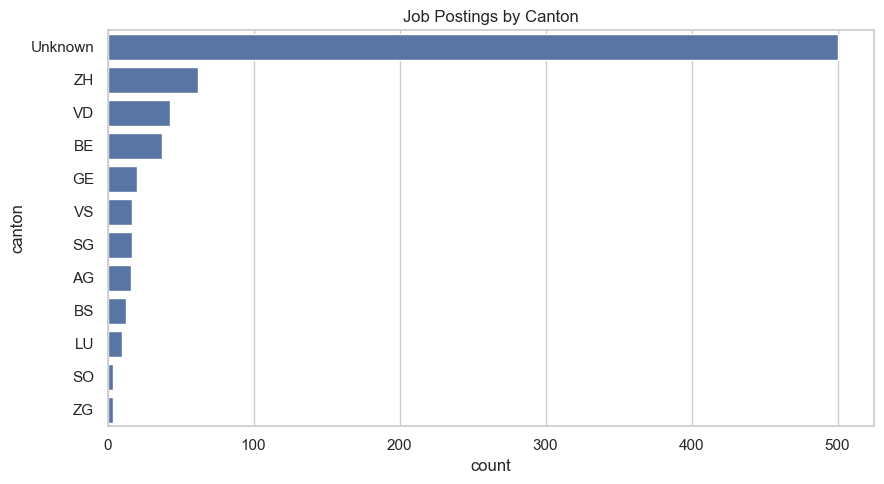

In [92]:
plt.figure(figsize=(9,5))

sns.countplot(
    y="canton",
    data=df,
    order=df["canton"].value_counts().index
)

plt.title("Job Postings by Canton")
plt.tight_layout()
plt.show()

*Figure: Distribution of job postings by canton.*

The geographic distribution shows that job postings are concentrated in a limited number of cantons, particularly Zurich (ZH), Vaud (VD), and Bern (BE). These regions correspond to major economic and technology hubs in Switzerland where demand for digital and analytical skills is likely to be highest.

However, a large number of postings are labeled as “Unknown” because the exact location could not be extracted from the source website. This limits the precision of the regional analysis.

## Salary Transparency

The results show that salary information is available only in a portion of job postings, indicating limited salary transparency in the Swiss job market. This supports the relevance of salary disclosure as a key analytical dimension in this project.

In [93]:
salary_rate = df["salary_available"].mean()

print("Salary transparency rate:", round(salary_rate*100,2), "%")

Salary transparency rate: 18.44 %


The results show that salary information is provided in only about 18% of job postings. This indicates relatively low salary transparency in the Swiss job market. Many employers appear to omit salary details in job advertisements, possibly revealing compensation information later during the recruitment process.

## Initial Observations

The exploratory analysis shows that the dataset contains 743 job postings related to data-oriented roles, including positions such as Data Analyst, Data Scientist, and Data Engineer.

The postings are concentrated in selected cantons and industries, reflecting the structure of the Swiss data job market. In addition, salary information is only available for a subset of advertisements, indicating limited salary transparency.

Overall, the EDA provides a solid foundation for the next stage of the project, where the research questions will be examined in more detail.

## Data Limitations

Several limitations of the dataset should be noted. First, a large number of job postings do not contain precise location information, which results in many entries labeled as "Unknown". This limits the accuracy of regional comparisons.

Second, all job postings in the dataset are mapped to the ICT sector (NOGA 58–63). As a result, meaningful comparisons across industries are not possible in the current dataset.

These limitations should be considered when interpreting the results of the following analyses.

___


# Research Question Analysis

After completing the exploratory data analysis, the following sections examine the research questions defined in the feasibility study. These analyses focus on skill demand, regional differences in job postings, and salary transparency patterns in the Swiss data job market.

## Skills Demand

The first research question investigates which skills are most commonly required in Swiss data-related job postings. By analyzing the number of skills mentioned in job advertisements, we can gain insight into the complexity and diversity of skill requirements in the data job market.

### Average Skill Count by Role

The number of skills mentioned in job postings can provide insight into the complexity and breadth of job requirements for different roles. By comparing the average number of listed skills across roles, it is possible to understand which positions tend to require broader technical competencies.

In [94]:
avg_skill_by_role = (
    df.groupby("role")["skill_count"]
    .mean()
    .sort_values(ascending=False)
)

avg_skill_by_role

role
machine learning engineer    3.166667
data scientist               1.934426
ai engineer                  1.777778
data analyst                 0.947368
data engineer                0.770089
Name: skill_count, dtype: float64

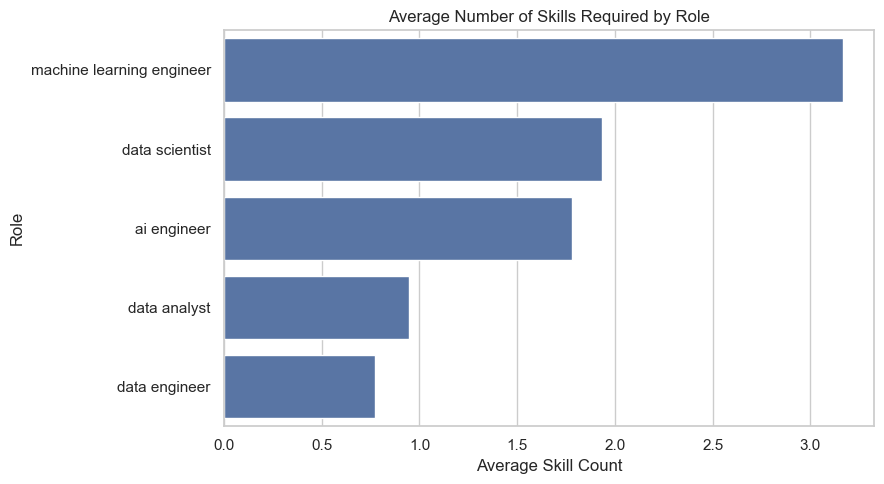

In [95]:
plt.figure(figsize=(9,5))

sns.barplot(
    x=avg_skill_by_role.values,
    y=avg_skill_by_role.index
)

plt.title("Average Number of Skills Required by Role")
plt.xlabel("Average Skill Count")
plt.ylabel("Role")

plt.tight_layout()
plt.show()

*Figure: Average number of skills required by role.*

The results show that some roles require a larger number of skills than others. Positions such as Machine Learning Engineer and Data Scientist tend to involve more diverse skill requirements, reflecting the technical complexity of these roles. In contrast, Data Analyst and Data Engineer positions list fewer explicit skills in job advertisements, which may reflect differences in how job requirements are described across roles.

### Top 15 Most Frequently Requested Skills

To better understand which technologies are most demanded in the Swiss data job market, the skills extracted from job postings are analyzed. The following chart shows the most frequently mentioned skills across all job advertisements in the dataset.

In [96]:
import ast
from collections import Counter

def parse_skills(x):
    try:
        return [s.strip().lower() for s in ast.literal_eval(x)]
    except:
        return []

df["skills_list"] = df["skills"].apply(parse_skills)

all_skills = []

for skills in df["skills_list"]:
    all_skills.extend(skills)

skill_counts = Counter(all_skills)

top_skills = pd.DataFrame(
    skill_counts.most_common(15),
    columns=["skill","count"]
)

top_skills

,skill,count
0,python,165
1,sql,99
2,azure,96
3,machine learning,74
4,kubernetes,55
5,aws,54
6,r,54
7,docker,49
8,git,44
9,gcp,34


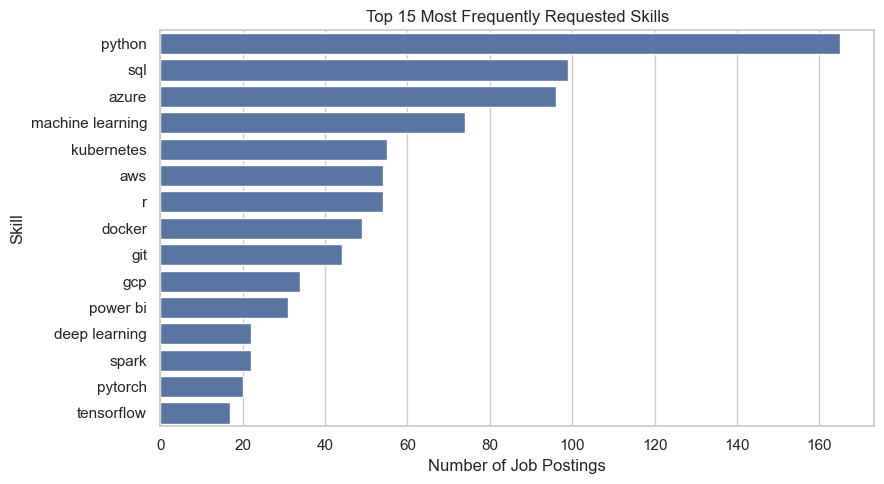

In [97]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=top_skills,
    x="count",
    y="skill"
)

plt.title("Top 15 Most Frequently Requested Skills")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")

plt.tight_layout()
plt.show()

*Figure: Top 15 most frequently requested skills in Swiss data-related job postings.*

The chart highlights the most frequently requested skills in Swiss data-related job postings. These technologies represent the core technical competencies expected from candidates in the data job market.

The presence of programming languages, data analysis tools, and machine learning frameworks indicates that modern data roles require a combination of programming, statistical analysis, and data processing capabilities.

## Regional Differences

The second research question examines whether job postings differ across regions in Switzerland. One way to explore regional differences is to compare salary transparency across cantons. By analyzing the proportion of job advertisements that include salary information in each canton, we can identify whether some regions are more transparent about compensation than others.

Because many job postings do not contain precise location information, some entries are labeled as "Unknown". These entries are excluded from the regional comparison to ensure that the analysis focuses only on clearly identified cantons.

In [98]:
salary_region = (
    df[df["canton"] != "Unknown"]
    .groupby("canton")["salary_available"]
    .mean()
    .sort_values(ascending=False)
)

salary_region



canton
BS    0.384615
AG    0.312500
ZH    0.241935
SG    0.235294
BE    0.189189
GE    0.150000
LU    0.100000
VD    0.069767
SO    0.000000
VS    0.000000
ZG    0.000000
Name: salary_available, dtype: float64

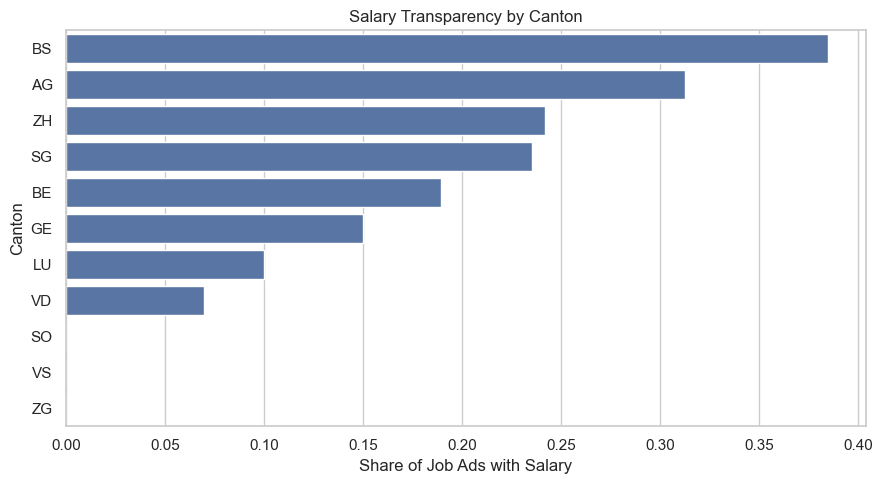

In [99]:
plt.figure(figsize=(9,5))

sns.barplot(
    x=salary_region.values,
    y=salary_region.index
)

plt.title("Salary Transparency by Canton")
plt.xlabel("Share of Job Ads with Salary")
plt.ylabel("Canton")

plt.tight_layout()
plt.show()

*Figure: Salary transparency by role.*

The results suggest that salary transparency varies across Swiss cantons. Some regions show a higher proportion of job postings that include salary information, while others display lower levels of transparency. However, these findings should be interpreted with caution because some cantons contain relatively small numbers of job postings, which may influence the calculated proportions.

## Salary Transparency Patterns

The final research question focuses on patterns in salary transparency across different job roles. By comparing salary disclosure rates across roles, we can determine whether certain positions are more likely to include salary information in job advertisements.

In [100]:
salary_role = df.groupby("role")["salary_available"].mean().sort_values(ascending=False)

salary_role

role
ai engineer                  0.250000
data engineer                0.187500
data analyst                 0.178947
machine learning engineer    0.166667
data scientist               0.163934
Name: salary_available, dtype: float64

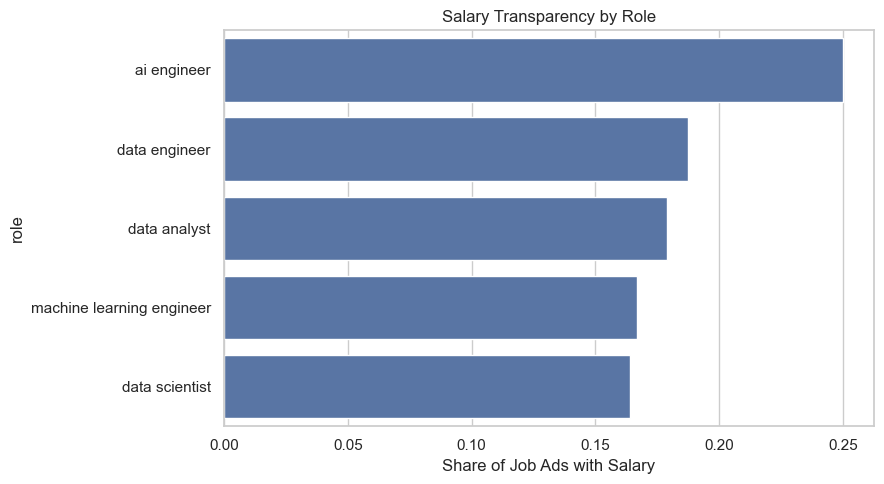

In [101]:
plt.figure(figsize=(9,5))

sns.barplot(
    x=salary_role.values,
    y=salary_role.index
)

plt.title("Salary Transparency by Role")

plt.xlabel("Share of Job Ads with Salary")
plt.tight_layout()
plt.show()

*Figure: Salary transparency by role.*

The analysis indicates that salary transparency varies slightly across job roles. Some roles, such as AI Engineer and Data Engineer, show higher rates of salary disclosure, while others provide salary information less frequently. However, overall transparency remains relatively low across all roles.

## Summary of Findings

The analysis reveals several important patterns in the Swiss data job market. Data Engineer roles appear most frequently in the dataset, followed by Data Scientist and Data Analyst positions. Skill requirements vary across roles, with technically specialized positions requiring a broader set of competencies.

Job opportunities are concentrated in key cantons such as Zurich, Vaud, and Bern, reflecting the presence of major economic and technological hubs. However, many job postings lack precise location information, which limits the completeness of the regional analysis.

Finally, salary transparency remains limited, with only about 18% of job advertisements including salary information. This suggests that many employers prefer to disclose compensation details later in the recruitment process.